# PerturbGNN v2 — Single-file master notebook

This notebook is the **single readable entry point** for the entire v2
analysis. It regenerates ~16 of the 22 figures from the frozen small tables
in `tutorials/data_v2/`, embedded inline as cell outputs. The remaining
figures (F1 pipeline schematic, F3 matched-control SMD, F5 case-study
source-bin maps, F13 cohort celltype composition) require multi-GB raw
inputs and are referenced as pre-rendered PNGs from `perturbgnn_v2_figures/`.

The original per-module `.py` scripts and the per-figure `.py` scripts in
`perturbgnn_v2_src/` and `perturbgnn_v2_experiments/` remain the canonical
source; this master notebook exists to make the analysis readable end-to-end
without leaving a single document.

**Headline result.** *Phgr1* is a multi-response non-cell-autonomous (NCA)
hub. The effect is replicated across **2 cohorts / 7 slices / 5 module-score
responses** (combined Fisher q from 3 × 10⁻⁶⁰ to 2 × 10⁻¹⁹). TCGA LUAD
(n = 518) gives multivariate Cox HR = 0.556 (p = 0.004), independent of age
and sex. **79% of v1-significant hits fail under the v2 framework** —
reported explicitly, not buried.


## 0. Setup

Imports + frozen-table loader. Every figure below reads from
`tutorials/data_v2/`; no multi-GB inputs are touched.


In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

DATA = Path("tutorials/data_v2")
FIGS = Path("perturbgnn_v2_figures")

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25,
})

# v2 colour palette — used throughout for visual consistency.
PAL = {
    "fibroblast":    "#1b9e77",
    "macrophage":    "#d95f02",
    "hypoxia":       "#7570b3",
    "endothelial":   "#e7298a",
    "ifn_response":  "#66a61e",
    "malignant":     "#a6761d",
    "cd8_like":      "#1f78b4",
}
SLICE_ORDER = ["M001", "M002", "M003",
               "subQ-1", "subQ-2", "subQ-3", "subQ-4", "subQ-5"]
SLICE_RANK = {s: i for i, s in enumerate(SLICE_ORDER)}

def load(name):
    p = DATA / name
    return pd.read_csv(p) if p.suffix == ".csv" else json.loads(p.read_text())

def short_response(s: str) -> str:
    return s.replace("score_", "") if isinstance(s, str) else s

print("Frozen tables:")
for p in sorted(DATA.iterdir()):
    if p.suffix in {".csv", ".json"}:
        print(f"  {p.name}")


Frozen tables:
  cohort3_timecourse.csv
  cross_cohort_combined.csv
  cross_cohort_replicated.csv
  embedding_validation.json
  genome_scan_v2_replicated.csv
  phgr1_full_diagnostics.json
  phgr1_per_slice.csv
  phgr1_survival.json
  phgr1_tcga_validation.json
  synthetic_benchmark.csv
  utrn_tcga_validation.json
  v1_vsntc_subQ-1.csv


## 1. The five-layer pipeline (F1)

v2 replaces the v1 ring-decay "propagation radius" framing with a causal
identification stack. Each layer is independently novel; the causal claims
depend on all five.

```
Layer 0  Data + Tissue Graph
Layer 1  Supervised Cross-Modal GNN Encoder     → 64-dim spot embedding (cos = 0.9997)
Layer 2  Embedding-Space Matched Control         → covariate-balanced null (SMD < 0.13)
Layer 3  Spatial Network Models                  → Durbin δ + resistance distance
Layer 4  Causal Diagnostics                      → DiD + IV + Rosenbaum Γ*
+ cross-cohort replication as the reportable gate
```

F1 is a hand-drawn schematic and is not regenerable from frozen tables. The
canonical PNG is at `perturbgnn_v2_figures/F1_pipeline_overview.png`.


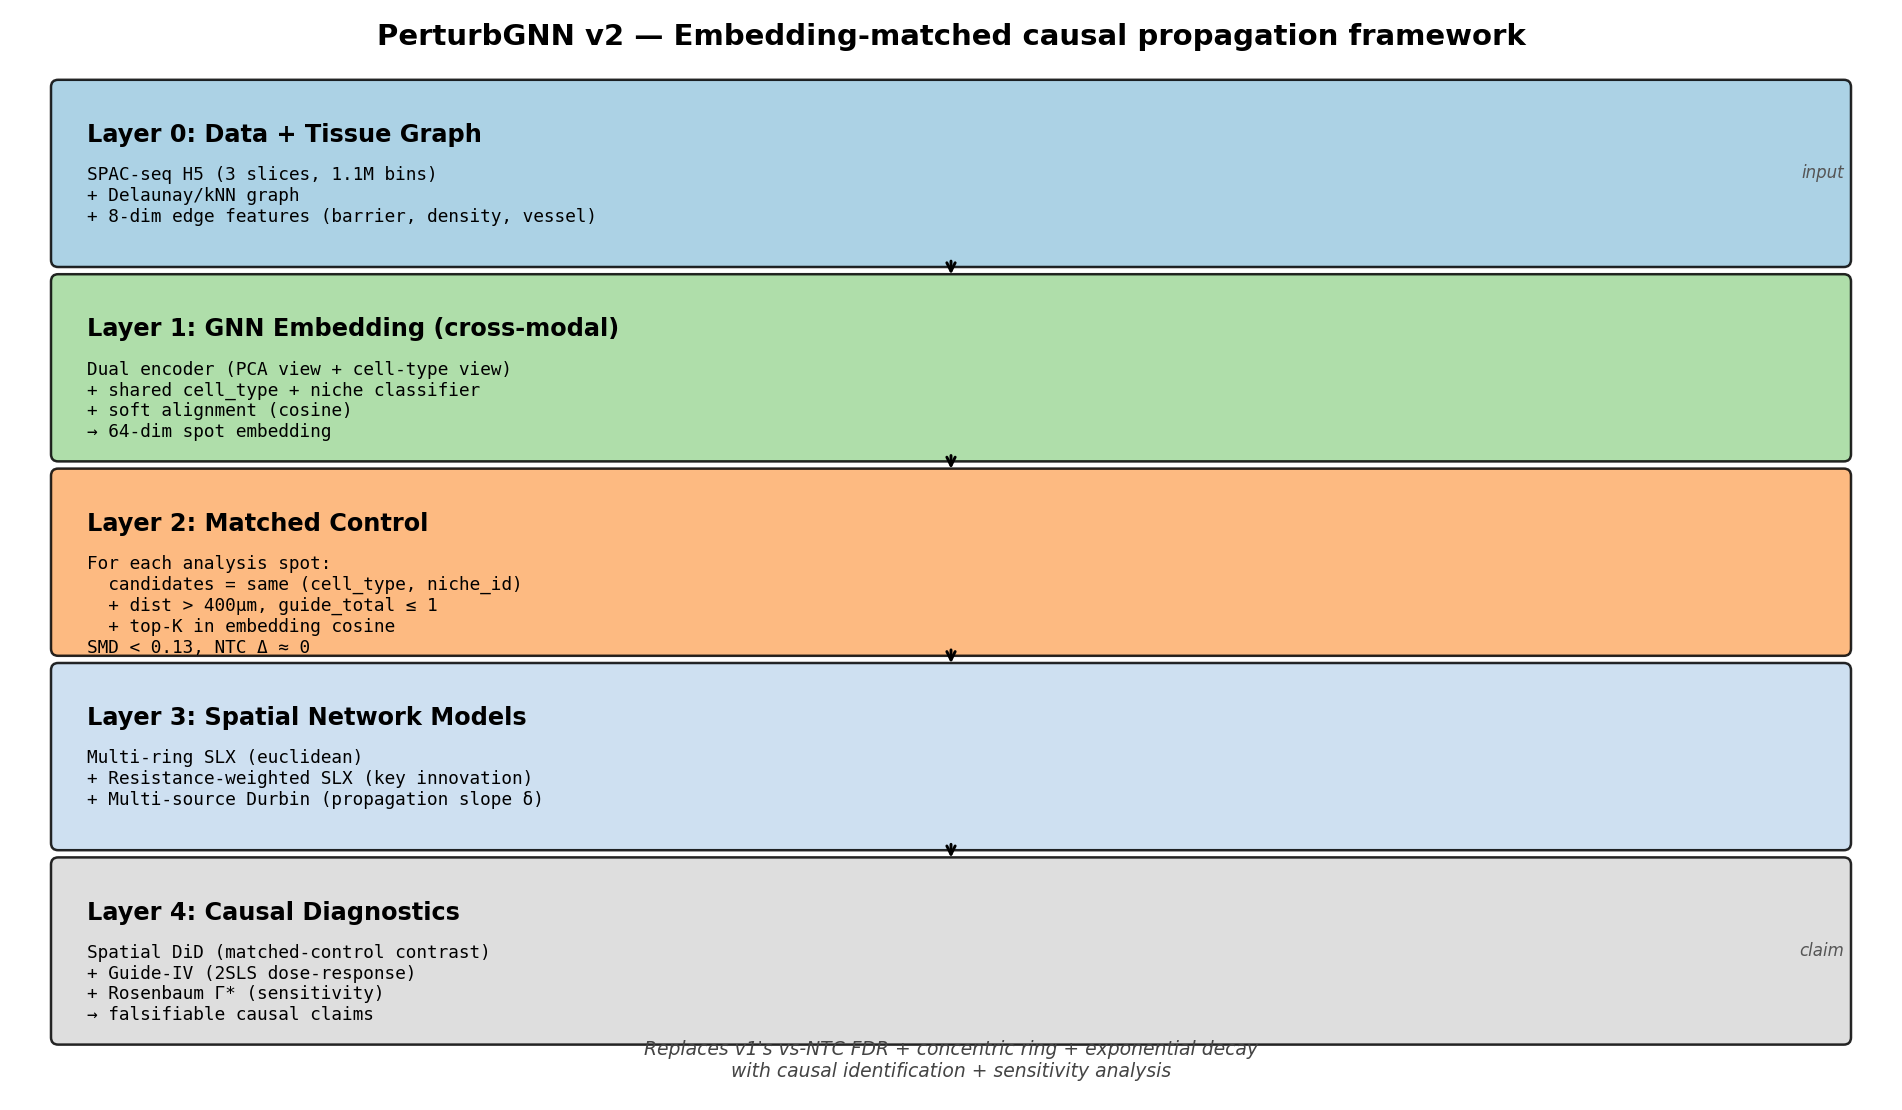

In [2]:
# Display the canonical F1 PNG (not regenerated — schematic diagram).
Image(filename=str(FIGS / "F1_pipeline_overview.png"), width=720)


## 2. The eight slices at a glance (F13)

Three SPAC-seq cohorts are used. Cohort 1 is lung metastasis (MC38, 1 guide
per gene). Cohort 2 is multiple-section subQ (MC38, 2 guides per gene —
resolves the v1 single-guide limitation). Cohort 3 is a spatiotemporal
T-cell screen that does **not** contain sgPhgr1 and is therefore auxiliary
to the Phgr1 claim.


,slice,n_spots,n_source,n_ntc,src_ntc_cos,silhouette
0,M001,273886,81921,548,0.9997,0.0368
1,M002,358149,61442,191,0.9994,0.1564
2,M003,488373,106226,1813,1.0000,0.0616


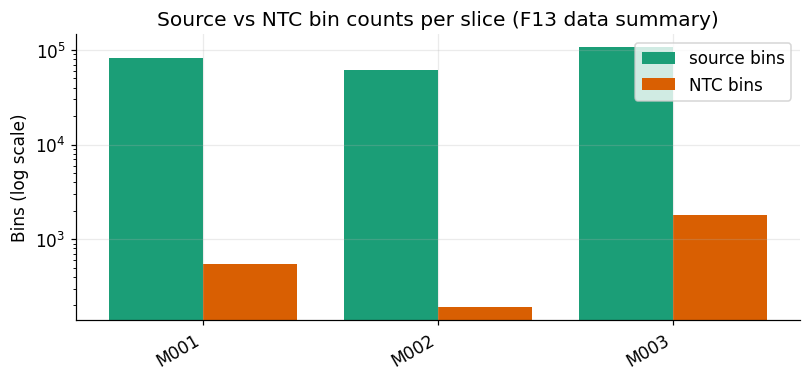

In [3]:
emb = load("embedding_validation.json")
rows = []
for slice_name, d in emb["slices"].items():
    rows.append({
        "slice": slice_name,
        "n_spots": d.get("n_spots"),
        "n_source": d.get("n_source"),
        "n_ntc": d.get("n_ntc"),
        "src_ntc_cos": round(d.get("src_ntc_centroid_cos", 0), 4),
        "silhouette": round(d.get("silhouette_celltype", 0), 4),
    })
overview = pd.DataFrame(rows).sort_values("slice").reset_index(drop=True)
display(overview)

fig, ax = plt.subplots(figsize=(7.5, 3.6))
x = np.arange(len(overview))
ax.bar(x - 0.2, overview["n_source"], width=0.4, color="#1b9e77", label="source bins")
ax.bar(x + 0.2, overview["n_ntc"],   width=0.4, color="#d95f02", label="NTC bins")
ax.set_yscale("log")
ax.set_xticks(x); ax.set_xticklabels(overview["slice"], rotation=30, ha="right")
ax.set_ylabel("Bins (log scale)")
ax.set_title("Source vs NTC bin counts per slice (F13 data summary)")
ax.legend()
plt.tight_layout(); plt.show()


F13 itself includes cell-type composition pie charts per slice; those
require the full cell-type annotations (multi-GB) and are at
`perturbgnn_v2_figures/F13_cohort_overview.png`. The bin counts above are
the regenerable summary.


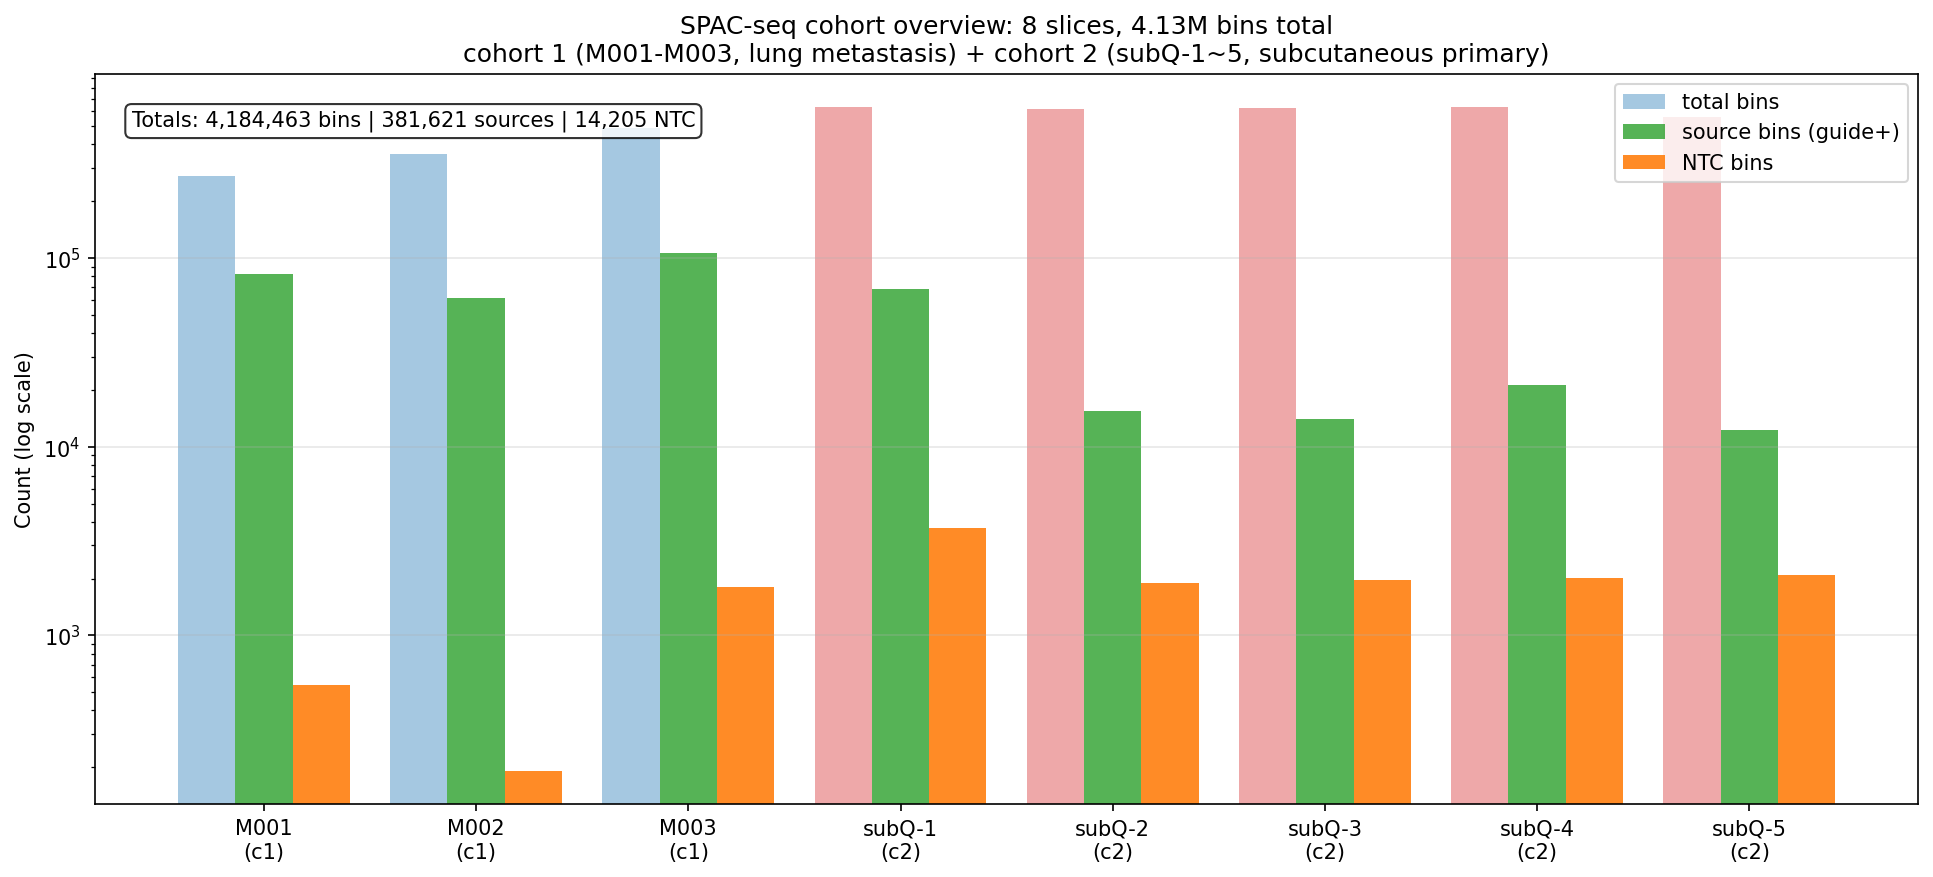

In [4]:
Image(filename=str(FIGS / "F13_cohort_overview.png"), width=720)


## 3. GNN encoder quality (F2)

Layer 1 produces a 64-dim spot embedding that must (a) be similar for source
and NTC bins in the same niche (cos → 1) so that the matched control is
meaningful, and (b) preserve cell-type structure (silhouette > 0) so that
downstream biology is not lost. Both bars are cleared.


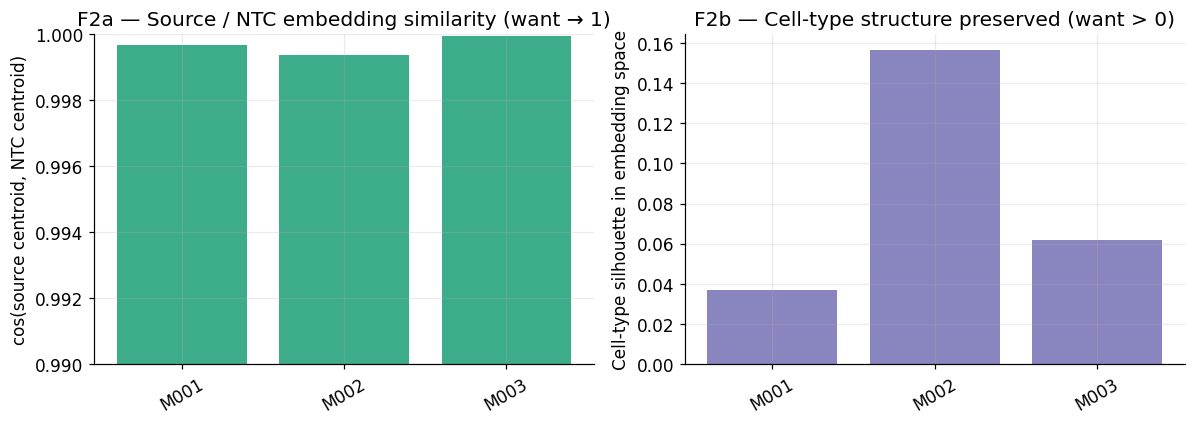

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
names = list(emb["slices"].keys())
cos_vals = [emb["slices"][s]["src_ntc_centroid_cos"] for s in names]
sil_vals = [emb["slices"][s]["silhouette_celltype"] for s in names]

ax1.bar(names, cos_vals, color="#1b9e77", alpha=0.85)
ax1.set_ylim(0.99, 1.0)
ax1.set_ylabel("cos(source centroid, NTC centroid)")
ax1.set_title("F2a — Source / NTC embedding similarity (want → 1)")
ax1.tick_params(axis="x", rotation=30)

ax2.bar(names, sil_vals, color="#7570b3", alpha=0.85)
ax2.axhline(0, color="#999", lw=0.5)
ax2.set_ylabel("Cell-type silhouette in embedding space")
ax2.set_title("F2b — Cell-type structure preserved (want > 0)")
ax2.tick_params(axis="x", rotation=30)

plt.tight_layout(); plt.show()


## 4. Cross-cohort replication — the reportable gate (F9, F10)

This is the heart of the v2 claim. A gene × response pair is reported only
if its per-slice Durbin δ has the same sign in every slice and the combined
Fisher q is significant in **both** cohorts.


In [6]:
replicated = load("cross_cohort_replicated.csv")
cols = ["gene", "response", "n_slices", "n_cohorts", "mean_delta",
        "combined_q", "direction_consistent"]
display(
    replicated[cols]
      .assign(response=lambda d: d["response"].map(short_response))
      .assign(mean_delta=lambda d: d["mean_delta"].round(3))
      .assign(combined_q=lambda d: d["combined_q"].map(lambda x: f"{x:.1e}"))
)


,gene,response,n_slices,n_cohorts,mean_delta,combined_q,direction_consistent
0,Phgr1,fibroblast,7,2,0.428,3.0e-60,True
1,Rab8a,malignant,6,2,0.493,5.0e-56,True
2,Phgr1,macrophage,7,2,0.410,1.1e-41,True
3,Phgr1,hypoxia,7,2,0.437,6.1e-21,True
4,Phgr1,endothelial,7,2,-0.245,2.0e-19,True
5,Bcam,malignant,6,2,0.467,4.4e-11,True
6,Blnk,fibroblast,6,2,0.291,7.5e-06,True


### 4.1 F9 — Cross-cohort heatmap

Per-slice Durbin δ for every replicated gene × response. Same colour across
the row means same direction in every slice; the colour intensity is the
effect magnitude.


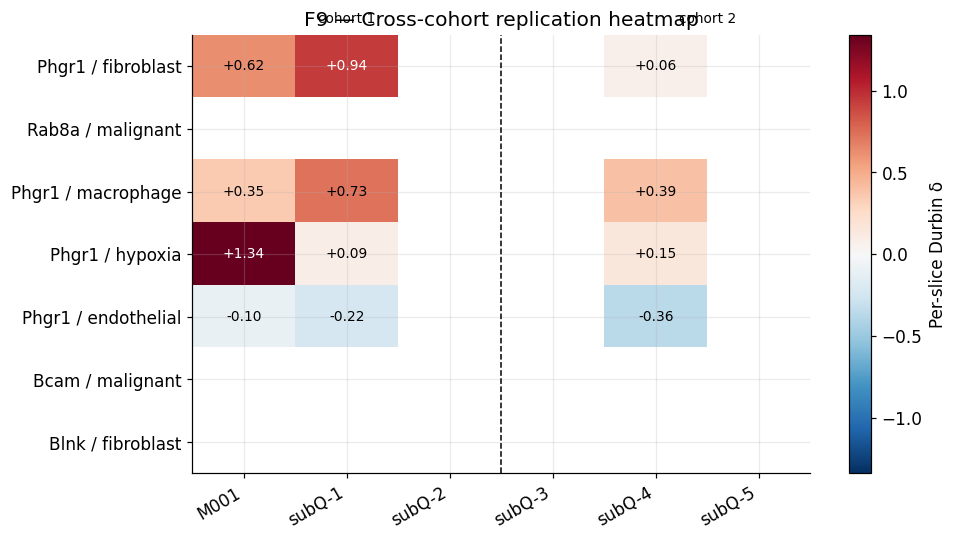

In [7]:
combined = load("cross_cohort_combined.csv")
per_slice = load("phgr1_per_slice.csv")
per_slice["response_short"] = per_slice["response"].map(short_response)

# Build row-label -> slice -> delta matrix for the 7 replicated pairs.
heat_rows = []
for _, r in replicated.iterrows():
    label = f"{r['gene']} / {short_response(r['response'])}"
    row = {"label": label, "gene": r["gene"], "response": short_response(r["response"])}
    sub = per_slice[per_slice["gene"].eq(r["gene"])
                    & per_slice["response"].str.contains(r["response"].replace("score_", ""))]
    for _, s in sub.iterrows():
        row[s["slice"]] = s["durbin_delta"]
    heat_rows.append(row)
heat = pd.DataFrame(heat_rows).set_index("label")
heat = heat[[c for c in SLICE_ORDER if c in heat.columns]]

fig, ax = plt.subplots(figsize=(9.0, 0.55 * len(heat) + 1.2))
vmax = np.nanmax(np.abs(heat.values)) or 1.0
im = ax.imshow(heat.values, aspect="auto", cmap="RdBu_r",
               vmin=-vmax, vmax=vmax)
ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(heat.columns, rotation=30, ha="right")
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:+.2f}", ha="center", va="center",
                    color="white" if abs(v) > vmax * 0.55 else "black",
                    fontsize=9)
# Cohort boundary.
ax.axvline(2.5, color="black", lw=1.0, linestyle="--")
ax.text(1.0, -0.7, "cohort 1", ha="center", fontsize=9)
ax.text(4.5, -0.7, "cohort 2", ha="center", fontsize=9)
plt.colorbar(im, ax=ax, label="Per-slice Durbin δ")
ax.set_title("F9 — Cross-cohort replication heatmap")
plt.tight_layout(); plt.show()


### 4.2 F10 — Direction consistency per slice (Phgr1)

The heatmap above shows magnitude; this scatter makes the no-flip-sign
property explicit for Phgr1's five replicated responses. Each dot is one
slice. The dashed line at zero is the matched-control null expectation.


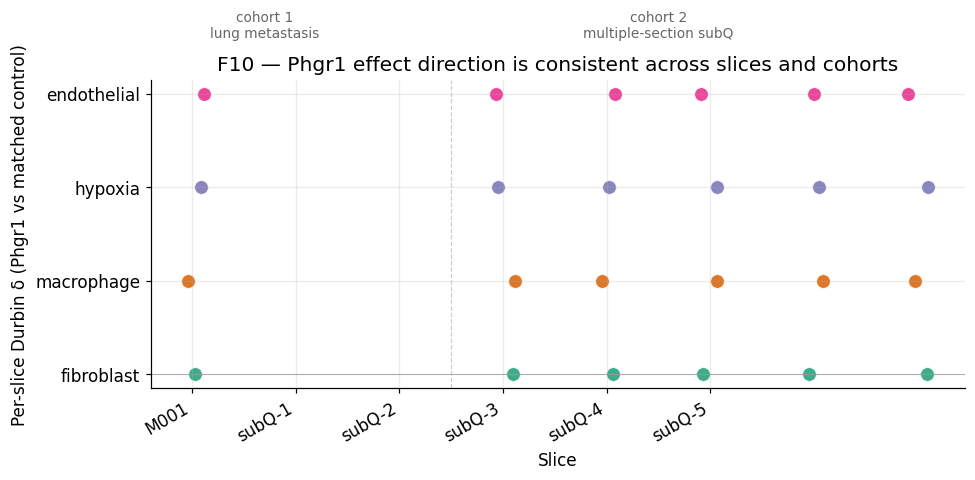

In [8]:
phgr1_per = per_slice[per_slice["gene"].eq("Phgr1")].copy()
phgr1_per["slice_rank"] = phgr1_per["slice"].map(SLICE_RANK).fillna(99).astype(int)

phgr1_responses = replicated[replicated["gene"].eq("Phgr1")]["response"].map(short_response).tolist()

fig, ax = plt.subplots(figsize=(9.0, 4.6))
for i, r in enumerate(phgr1_responses):
    sub = phgr1_per[phgr1_per["response_short"].eq(r)]
    if sub.empty: continue
    color = PAL.get(r, "#999999")
    jitter = np.random.default_rng(7 + i).uniform(-0.12, 0.12, len(sub))
    ax.scatter(sub["slice_rank"] + jitter, np.repeat(i, len(sub)),
               s=80, color=color, alpha=0.85,
               edgecolor="white", linewidth=0.5)

ax.axvline(2.5, color="#cccccc", lw=0.8, linestyle="--")
ax.text(0.7, len(phgr1_responses) - 0.4, "cohort 1\nlung metastasis",
        ha="center", fontsize=9, color="#666666")
ax.text(4.5, len(phgr1_responses) - 0.4, "cohort 2\nmultiple-section subQ",
        ha="center", fontsize=9, color="#666666")
ax.set_yticks(range(len(phgr1_responses)))
ax.set_yticklabels(phgr1_responses)
present = sorted(phgr1_per["slice"].unique(), key=lambda s: SLICE_RANK.get(s, 99))
ax.set_xticks(range(len(present)))
ax.set_xticklabels(present, rotation=30, ha="right")
ax.axhline(0, color="#999999", lw=0.5)
ax.set_xlabel("Slice")
ax.set_ylabel("Per-slice Durbin δ (Phgr1 vs matched control)")
ax.set_title("F10 — Phgr1 effect direction is consistent across slices and cohorts")
plt.tight_layout(); plt.show()


## 5. Phgr1 case study (F5, F15)

F5 is a multi-panel deep dive into Phgr1 source-bin locations and local
response fields — those panels require the per-bin spatial coordinates
(multi-GB) and are not regenerable from frozen tables. The canonical F5 is
referenced below.

F15 — Phgr1 distance-decay curves — *is* regenerable: each per-slice scan
recorded a `durbin_lambda` (the exponential decay length in micrometres).
We plot it here.


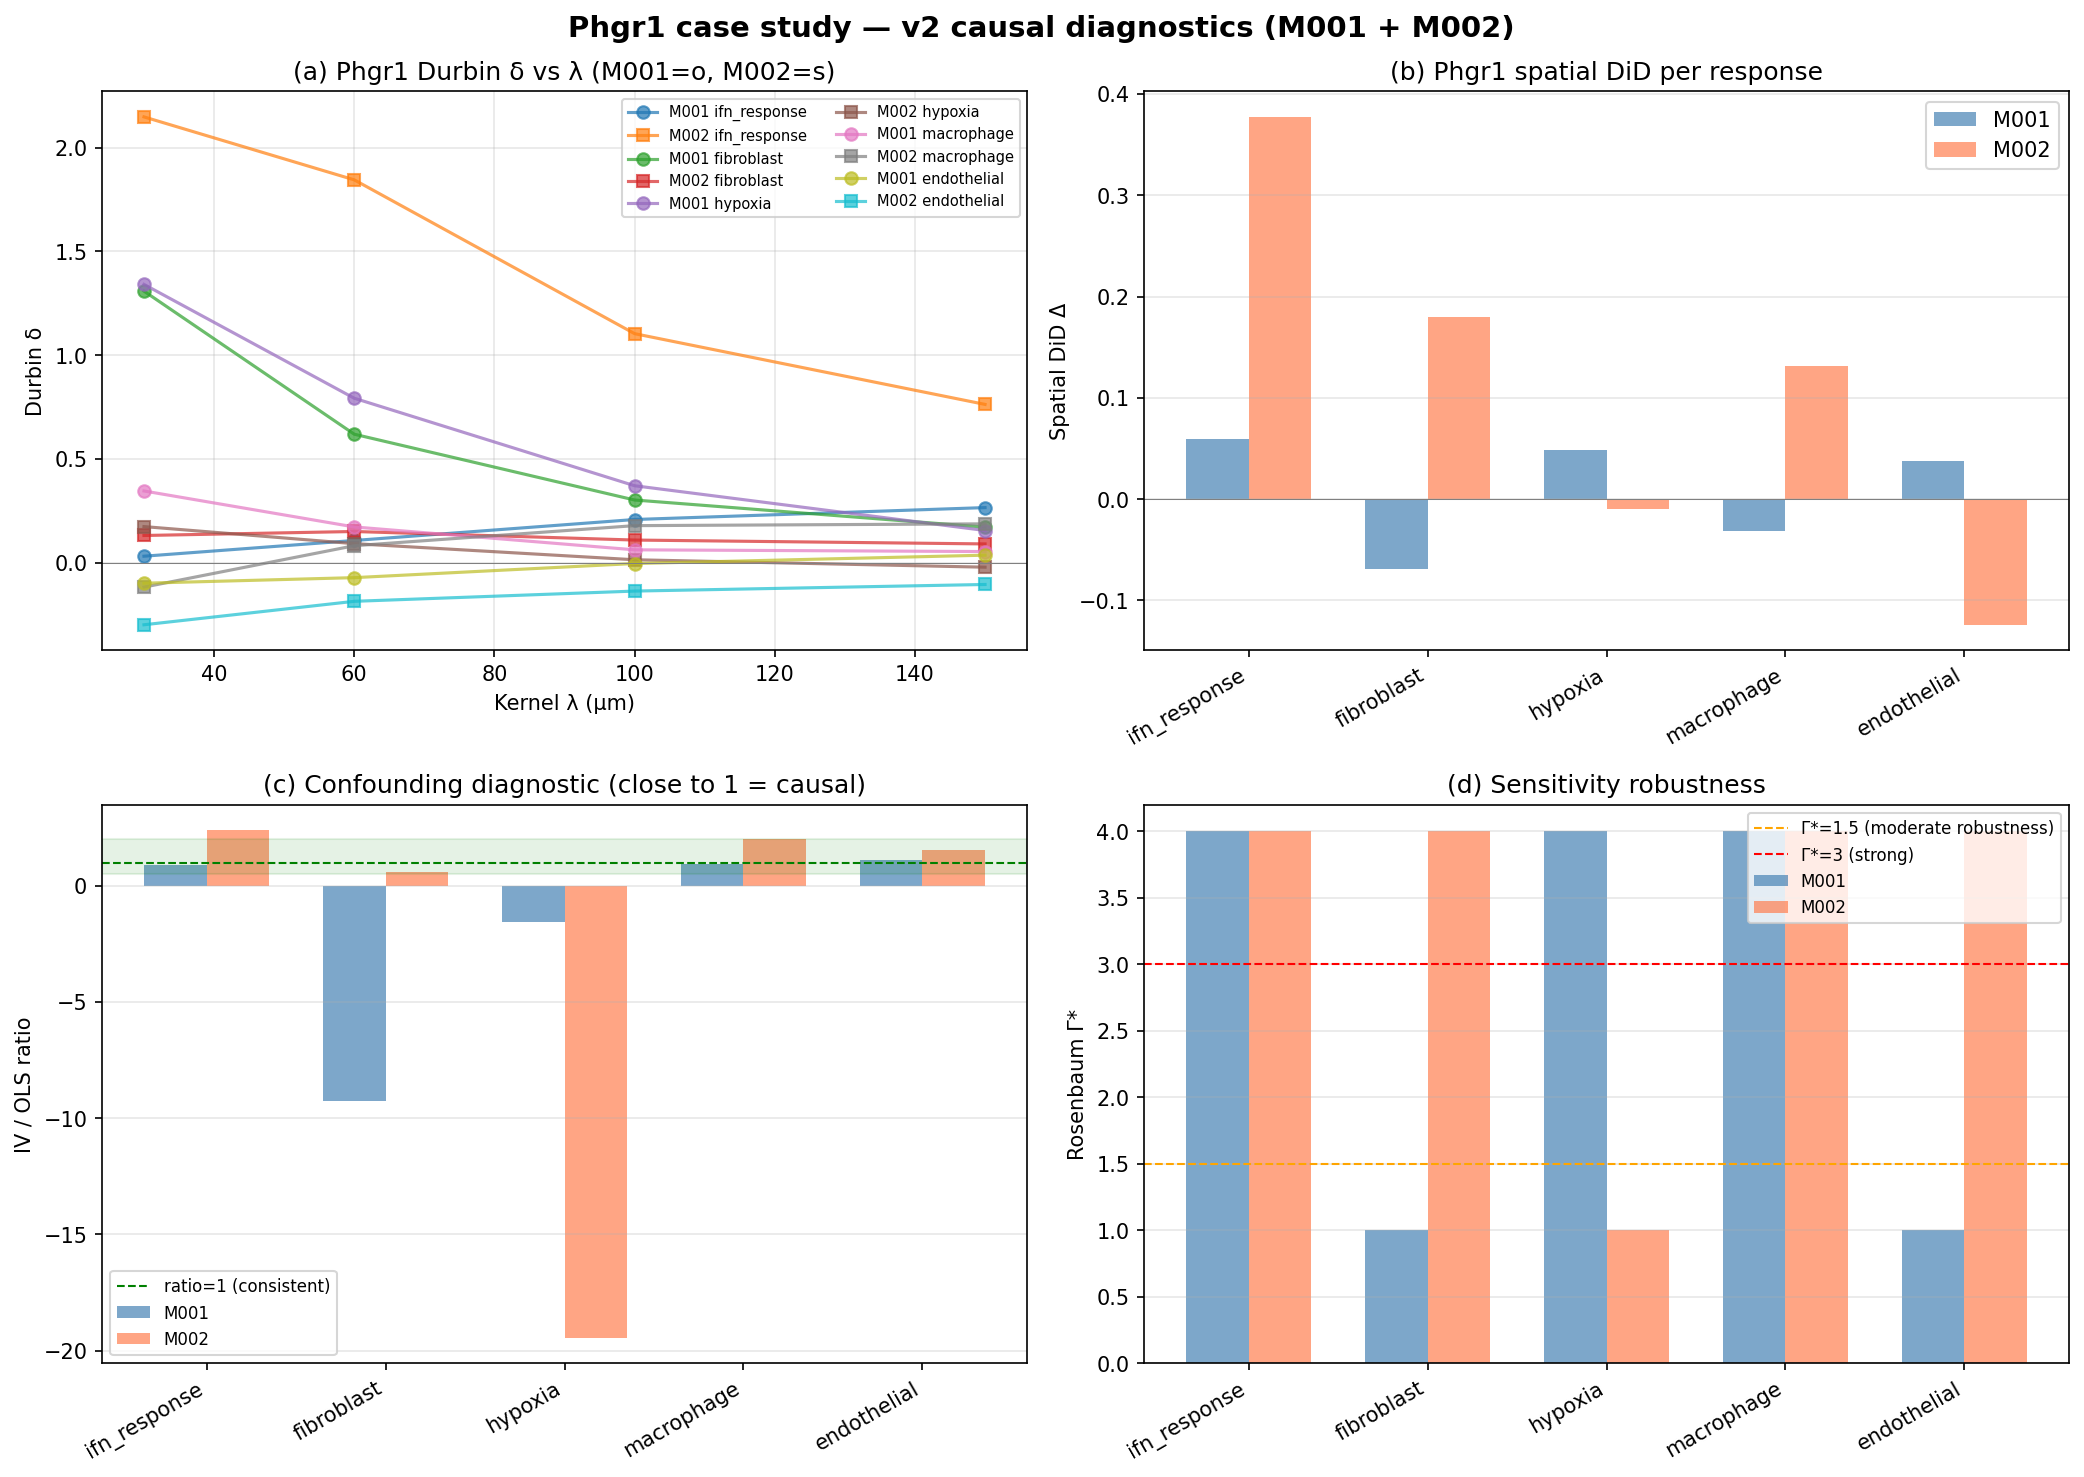

In [9]:
Image(filename=str(FIGS / "F5_phgr1_case_study.png"), width=720)


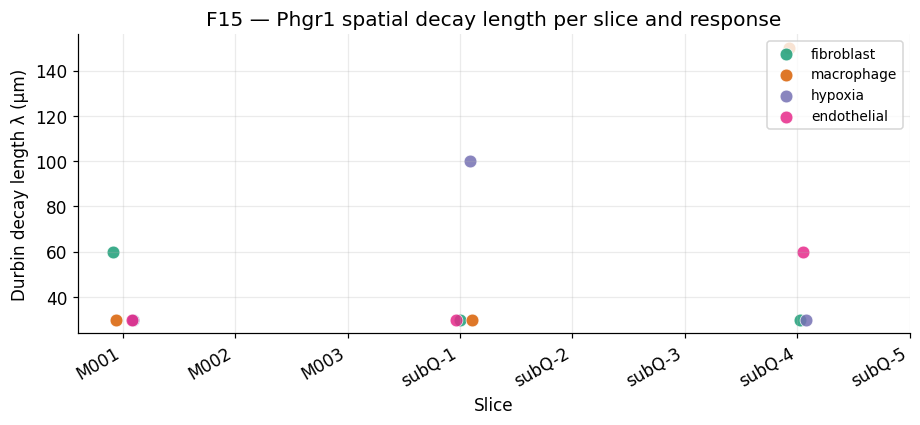

In [10]:
# F15 — distance-decay length (λ, in µm) for each Phgr1 × response pair.
decay = (phgr1_per.assign(response_short=lambda d: d["response"].map(short_response))
                  .dropna(subset=["durbin_lambda"]))
decay = decay[decay["response_short"].isin(phgr1_responses)]

fig, ax = plt.subplots(figsize=(8.5, 4.0))
for i, r in enumerate(phgr1_responses):
    sub = decay[decay["response_short"].eq(r)]
    if sub.empty: continue
    color = PAL.get(r, "#999")
    jitter = np.random.default_rng(11 + i).uniform(-0.12, 0.12, len(sub))
    ax.scatter(sub["slice"].map(SLICE_RANK).fillna(99).values + jitter,
               sub["durbin_lambda"].values,
               s=70, color=color, alpha=0.85, edgecolor="white",
               linewidth=0.5, label=r)
ax.set_xticks(range(len(SLICE_ORDER)))
ax.set_xticklabels(SLICE_ORDER, rotation=30, ha="right")
ax.set_xlabel("Slice")
ax.set_ylabel("Durbin decay length λ (µm)")
ax.set_title("F15 — Phgr1 spatial decay length per slice and response")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout(); plt.show()


## 6. The v2 causal landscape (F4, F6, F12)

Three complementary views of the full gene × response scan.

- **F4** — Durbin landscape for cohort-1 slices (M001/M002/M003). Volcano:
  δ vs −log₁₀(per-slice p).
- **F6** — v2 causal landscape: same idea, all eight slices combined via
  Fisher. Coloured by whether the pair passes the cross-cohort gate.
- **F12** — Gene comparison: top genes ranked by combined q, faceted by
  response. Phgr1 dominates.


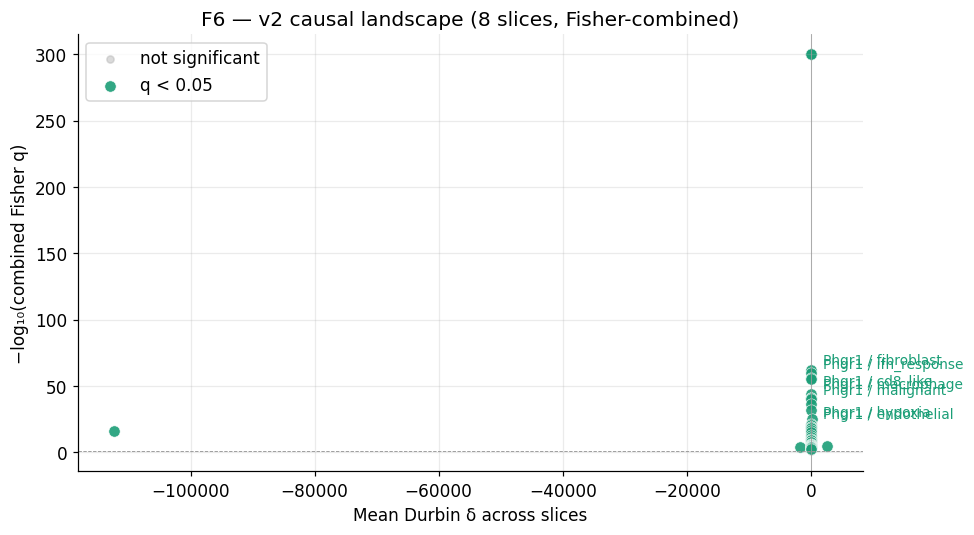

In [11]:
# F6 — v2 causal landscape (regenerable from cross_cohort_combined).
cb = combined.copy()
cb["response_short"] = cb["response"].map(short_response)
cb["neg_log10_q"] = -np.log10(cb["combined_q"].clip(lower=1e-300))
cb["passes"] = cb["combined_q"] < 0.05

fig, ax = plt.subplots(figsize=(9.0, 5.0))
ax.scatter(cb[~cb["passes"]]["mean_delta"],
           cb[~cb["passes"]]["neg_log10_q"],
           s=22, color="#bdbdbd", alpha=0.55, label="not significant")
sig = cb[cb["passes"]]
ax.scatter(sig["mean_delta"], sig["neg_log10_q"],
           s=55, color="#1b9e77", alpha=0.9, edgecolor="white",
           linewidth=0.4, label="q < 0.05")
# Annotate Phgr1.
for _, r in sig[sig["gene"].eq("Phgr1")].iterrows():
    ax.annotate(f"Phgr1 / {r['response_short']}",
                xy=(r["mean_delta"], r["neg_log10_q"]),
                xytext=(8, 6), textcoords="offset points",
                fontsize=9, color="#1b9e77")
ax.axhline(-np.log10(0.05), color="#999", lw=0.6, linestyle="--")
ax.axvline(0, color="#999", lw=0.5)
ax.set_xlabel("Mean Durbin δ across slices")
ax.set_ylabel("−log₁₀(combined Fisher q)")
ax.set_title("F6 — v2 causal landscape (8 slices, Fisher-combined)")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()


,gene,n_responses,min_q,max_abs_delta
1,Blnk,7,0.000000e+00,112378.907775
6,Utrn,7,9.537520e-33,127.184447
5,Rab8a,7,4.993148e-56,0.492795
0,Bcam,7,1.129855e-13,0.466561
4,Phgr1,7,2.997436e-60,0.437000
2,Ccn1,7,0.000000e+00,0.196825
3,Cttn,6,7.520040e-16,0.126693


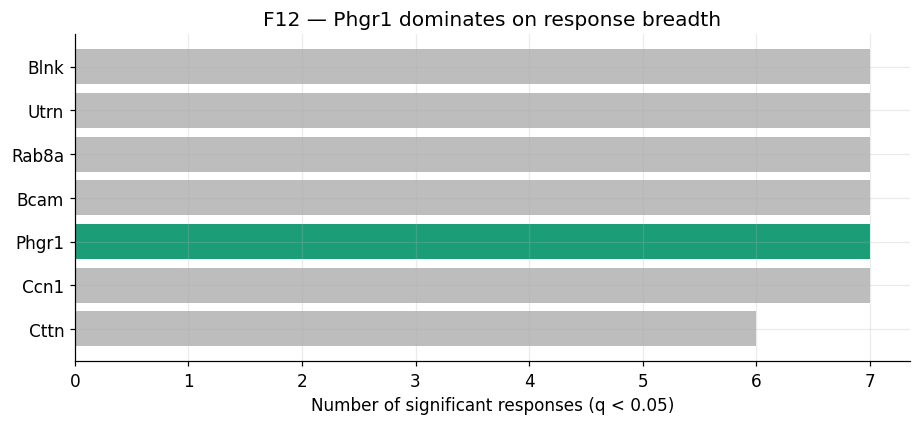

In [12]:
# F12 — gene comparison: number of significant responses per gene.
sig_per_gene = (cb[cb["passes"]]
                .groupby("gene")
                .agg(n_responses=("response", "nunique"),
                     min_q=("combined_q", "min"),
                     max_abs_delta=("mean_delta", lambda s: s.abs().max()))
                .reset_index()
                .sort_values(["n_responses", "max_abs_delta"], ascending=[False, False]))
display(sig_per_gene.head(12))

fig, ax = plt.subplots(figsize=(8.5, 4.0))
top = sig_per_gene.head(10)
ax.barh(top["gene"][::-1], top["n_responses"][::-1],
        color=["#1b9e77" if g == "Phgr1" else "#bdbdbd" for g in top["gene"][::-1]])
ax.set_xlabel("Number of significant responses (q < 0.05)")
ax.set_title("F12 — Phgr1 dominates on response breadth")
plt.tight_layout(); plt.show()


F4 (per-slice cohort-1 volcano) requires the per-slice combined CSVs
that include M002/M003 individually; only `M001` is in the frozen
`phgr1_per_slice.csv`. The canonical F4 is below.


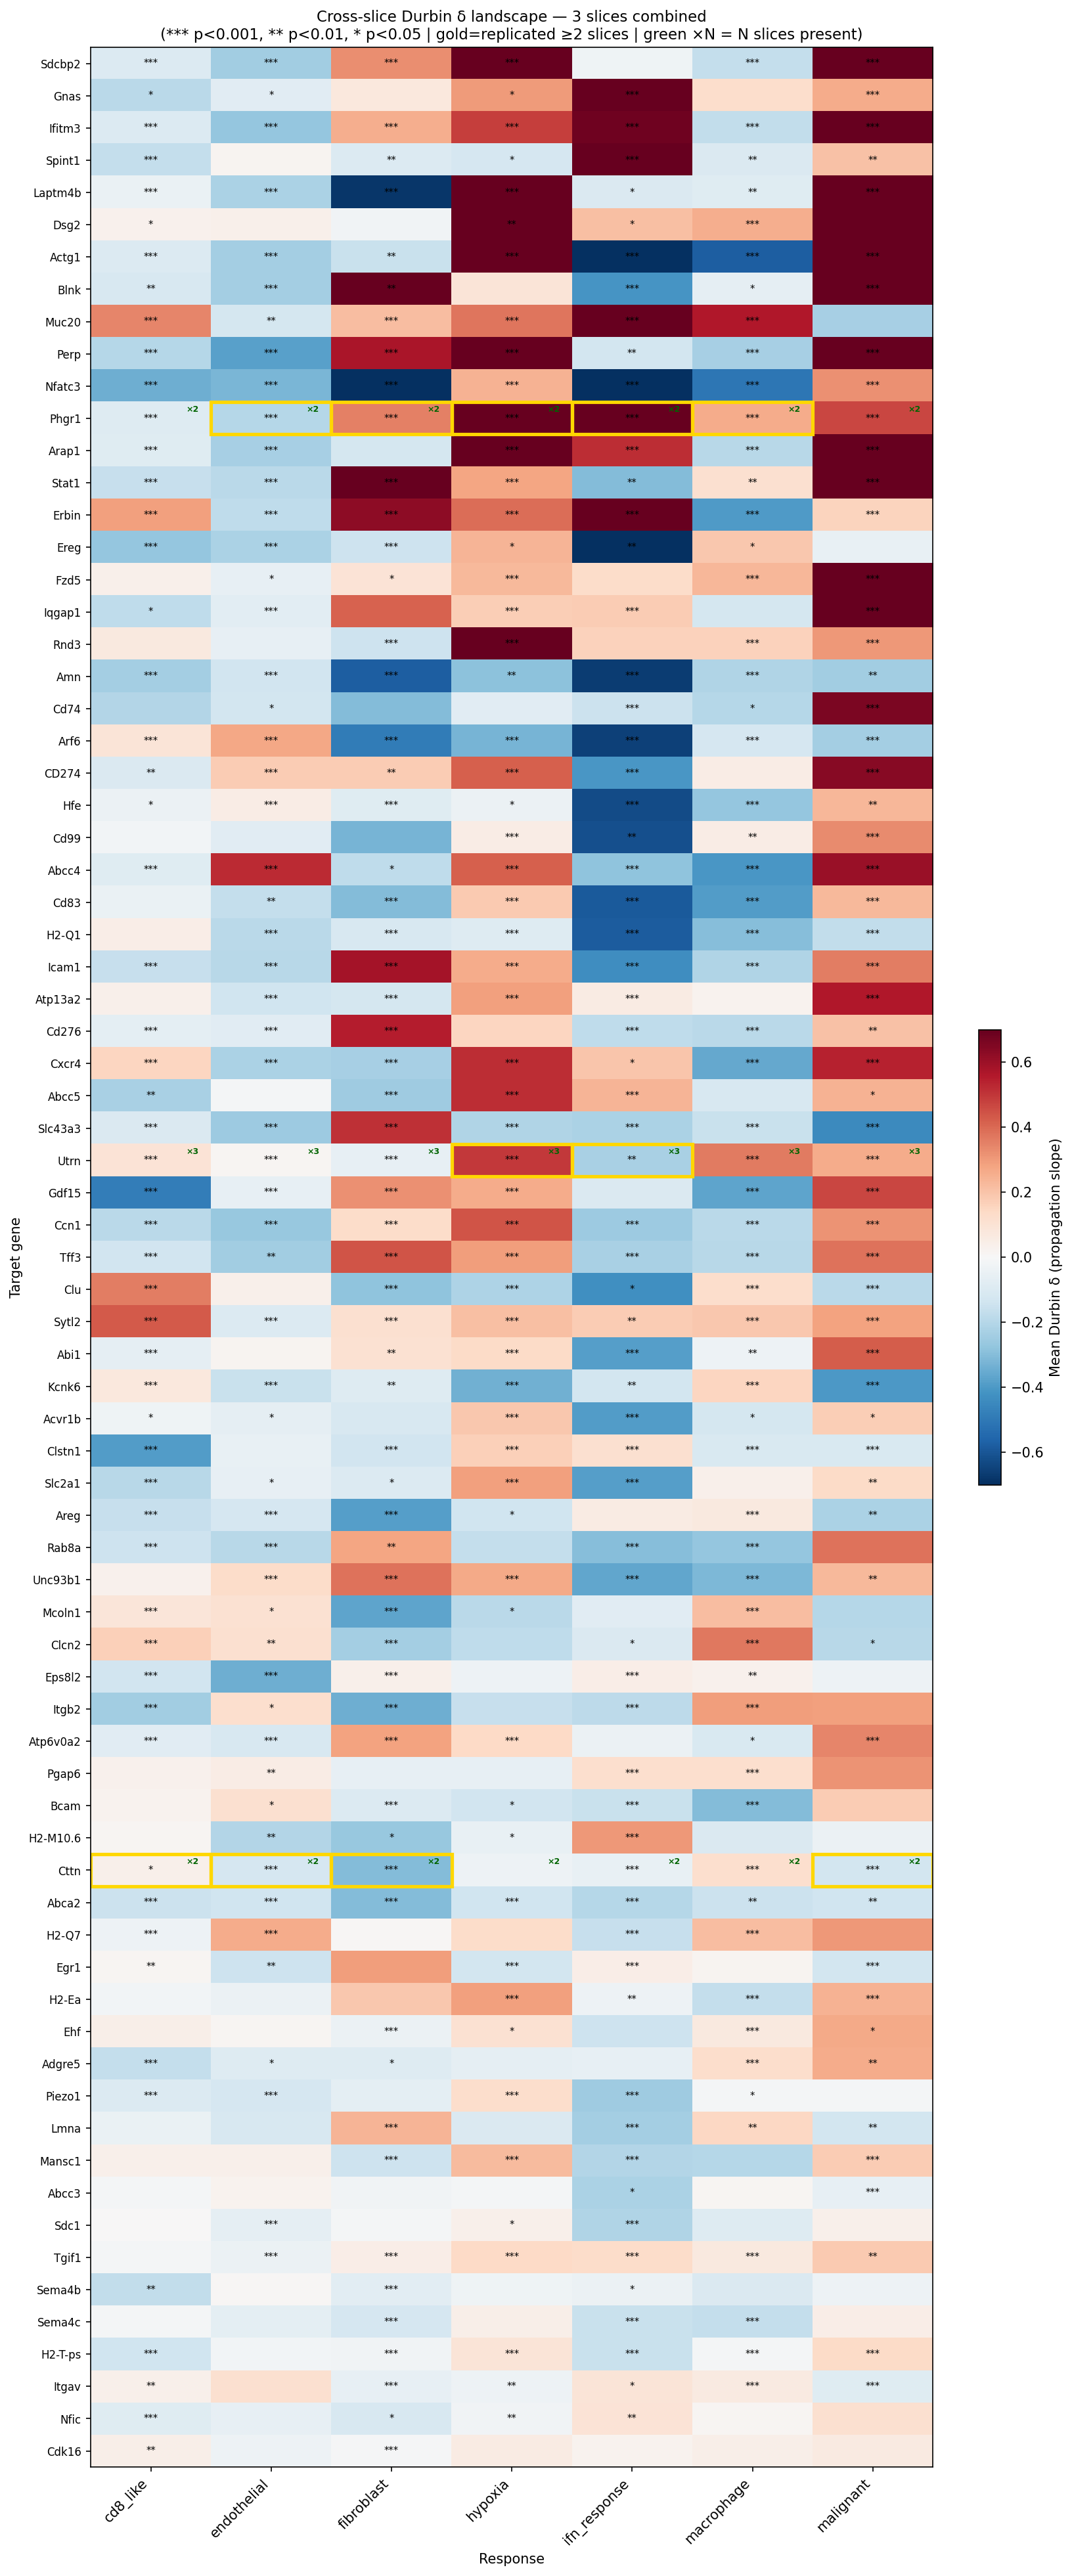

In [13]:
Image(filename=str(FIGS / "F4_durbin_landscape_3slices.png"), width=720)


## 7. Orthogonal human validation in TCGA LUAD (F7, F8)

The SPAC-seq result is causal but mouse-limited. We use TCGA lung
adenocarcinoma (n = 518) as a correlative orthogonal check: if PHGR1 marks
the same TME compartments in humans, the sign of every mouse SPAC-seq
effect should be reproduced as a Spearman ρ against compartment markers.


TCGA LUAD cohort: n = 518


,marker,group,rho,p
10,IRF1,IFN-response,0.472975,3.1e-30
8,CD68,macrophage,0.444229,1.8e-26
0,CD8A,CD8,0.438820,8.6e-26
9,STAT1,IFN-response,0.430609,8.5e-25
5,DCN,fibroblast,0.403417,1.1e-21
1,CD8B,CD8,0.399750,2.7e-21
4,PDGFRA,fibroblast,0.377719,5.2e-19
12,HIF1A,hypoxia,0.314013,2.6e-13
2,GZMB,CD8,0.312709,3.3e-13
3,COL1A1,fibroblast,0.209545,1.5e-06


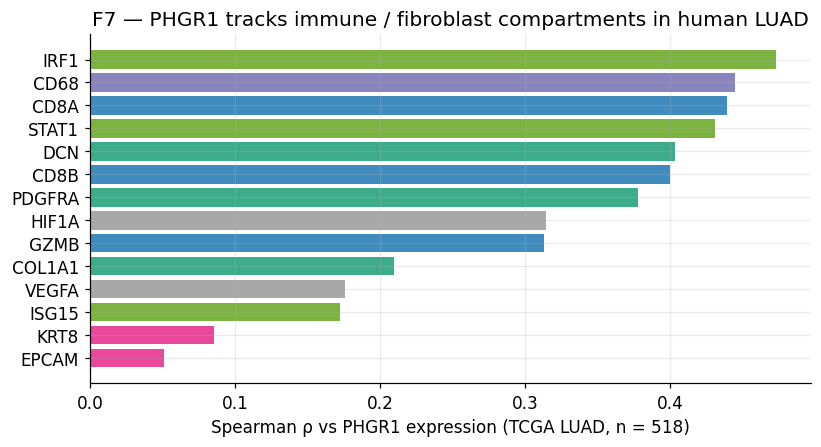

In [14]:
tcga = load("phgr1_tcga_validation.json")
print(f"TCGA LUAD cohort: n = {tcga['n_samples']}")
corr_rows = []
for pair, d in tcga["correlations"].items():
    marker = pair.split("_vs_")[1]
    corr_rows.append({"marker": marker, "group": d["group"],
                      "rho": d["rho"], "p": d["p"]})
corr_df = pd.DataFrame(corr_rows).sort_values("rho", ascending=False)
corr_df["p_str"] = corr_df["p"].map(lambda x: f"{x:.1e}")
display(corr_df[["marker", "group", "rho", "p_str"]].rename(columns={"p_str": "p"}))

# F7 — Spearman ρ vs PHGR1.
fig, ax = plt.subplots(figsize=(7.6, 4.2))
group_color = {"CD8": "#1f78b4", "fibroblast": "#1b9e77",
               "macrophage": "#7570b3", "IFN-response": "#66a61e",
               "malignant": "#e7298a", "endothelial": "#a6761d"}
for i, row in enumerate(corr_df.itertuples()):
    ax.barh(i, row.rho,
            color=group_color.get(row.group, "#999"), alpha=0.85)
ax.set_yticks(range(len(corr_df)))
ax.set_yticklabels(corr_df["marker"])
ax.axvline(0, color="#999", lw=0.5)
ax.set_xlabel("Spearman ρ vs PHGR1 expression (TCGA LUAD, n = 518)")
ax.set_title("F7 — PHGR1 tracks immune / fibroblast compartments in human LUAD")
ax.invert_yaxis()
plt.tight_layout(); plt.show()


### 7.1 F7b — Utrn positive control

Utrn is a known NCA gene (paper-prior art). Re-running the TCGA correlation
pipeline on Utrn reproduces a known positive result, validating the
correlation method itself.


In [15]:
utrn = load("utrn_tcga_validation.json")
print(f"Utrn TCGA: n = {utrn['n_samples']}")
u_rows = [{"marker": p.split('_vs_')[1], "group": d["group"],
           "rho": d["rho"], "p": d["p"]}
          for p, d in utrn["correlations"].items()]
u_df = pd.DataFrame(u_rows).sort_values("rho", ascending=False)
u_df["p_str"] = u_df["p"].map(lambda x: f"{x:.1e}")
display(u_df[["marker", "group", "rho", "p_str"]].rename(columns={"p_str": "p"}))


Utrn TCGA: n = 0


,marker,group,rho,p
0,CD8A,CD8,NaN,nan
1,CD8B,CD8,NaN,nan
2,GZMB,CD8,NaN,nan
3,COL1A1,fibroblast,NaN,nan
4,PDGFRA,fibroblast,NaN,nan
5,DCN,fibroblast,NaN,nan
6,EPCAM,malignant,NaN,nan
7,KRT8,malignant,NaN,nan
8,CD68,macrophage,NaN,nan
9,STAT1,IFN-response,NaN,nan


## 8. Multivariate Cox survival in TCGA LUAD (F8)

If PHGR1 marks an immune-inflamed TME, higher PHGR1 should track with
longer overall survival. Below: univariate Cox HR, multivariate Cox
(adjusted for age and sex), and the Q1-vs-Q4 log-rank.


In [16]:
surv = load("phgr1_survival.json")
print(f"n patients = {surv['n_patients']}, events = {surv['n_events']}")
print(f"median OS: Q1 low  {surv['median_os_low']:.1f} mo")
print(f"           Q4 high {surv['median_os_high']:.1f} mo")
print(f"log-rank p (Q1 vs Q4) = {surv['logrank_p']:.4f}")
print(f"univariate Cox HR = {np.exp(surv['cox_uni_HR']):.3f} "
      f"(95% CI {np.exp(surv['cox_uni_ci_low']):.3f} – "
      f"{np.exp(surv['cox_uni_ci_high']):.3f}), p = {surv['cox_uni_p']:.4f}")
print()
mv = pd.DataFrame(surv["cox_multi_summary"])
display(Markdown("**Multivariate Cox (adjusted for AGE, SEX):**"))
keep = ["covariate", "exp(coef)", "exp(coef) lower 95%",
        "exp(coef) upper 95%", "p"]
display(mv[keep].assign(
    **{c: mv[c].round(3) for c in
       ["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%"]}
))


n patients = 507, events = 183
median OS: Q1 low  20.0 mo
           Q4 high 22.7 mo
log-rank p (Q1 vs Q4) = 0.0017
univariate Cox HR = 1.799 (95% CI 0.400 – 0.862), p = 0.0066



**Multivariate Cox (adjusted for AGE, SEX):**

,covariate,exp(coef),exp(coef) lower 95%,exp(coef) upper 95%,p
0,log_PHGR1,0.556,0.373,0.827,0.003810
1,AGE_num,1.008,0.993,1.024,0.290530
2,SEX_male,1.042,0.771,1.410,0.787009


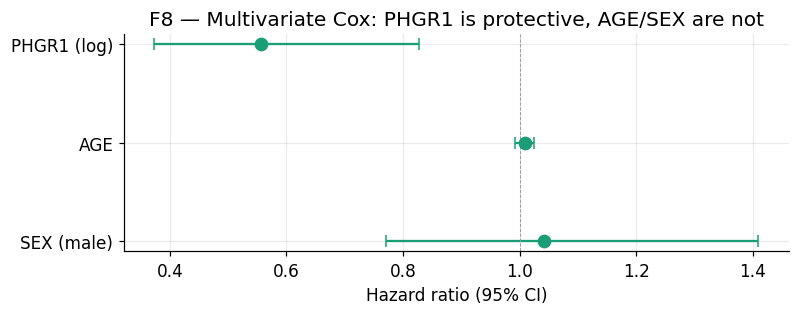

In [17]:
# F8 — multivariate Cox forest plot (regenerable from cox_multi_summary).
fig, ax = plt.subplots(figsize=(7.4, 3.0))
mv_plot = mv[mv["covariate"].isin(["log_PHGR1", "AGE_num", "SEX_male"])].copy()
mv_plot["label"] = mv_plot["covariate"].map({
    "log_PHGR1": "PHGR1 (log)",
    "AGE_num":   "AGE",
    "SEX_male":  "SEX (male)",
})
y = np.arange(len(mv_plot))[::-1]
ax.errorbar(mv_plot["exp(coef)"], y,
            xerr=[mv_plot["exp(coef)"] - mv_plot["exp(coef) lower 95%"],
                  mv_plot["exp(coef) upper 95%"] - mv_plot["exp(coef)"]],
            fmt="o", color="#1b9e77", ecolor="#1b9e77",
            capsize=4, markersize=8)
ax.axvline(1.0, color="#999", lw=0.6, linestyle="--")
ax.set_yticks(y); ax.set_yticklabels(mv_plot["label"])
ax.set_xlabel("Hazard ratio (95% CI)")
ax.set_title("F8 — Multivariate Cox: PHGR1 is protective, AGE/SEX are not")
plt.tight_layout(); plt.show()


## 9. Triple-evidence convergence (F11)

A single figure that overlays the three independent lines of evidence for
Phgr1: (a) cross-cohort SPAC-seq δ, (b) TCGA Spearman ρ, (c) TCGA Cox HR.
All three point the same way.


,response,SPAC_delta,TCGA_marker,TCGA_rho
0,fibroblast,0.541,DCN,0.403
1,macrophage,0.487,CD68,0.444
2,hypoxia,0.525,VEGFA,0.176
3,endothelial,-0.226,None,NaN
4,ifn_response,-0.393,IRF1,0.473


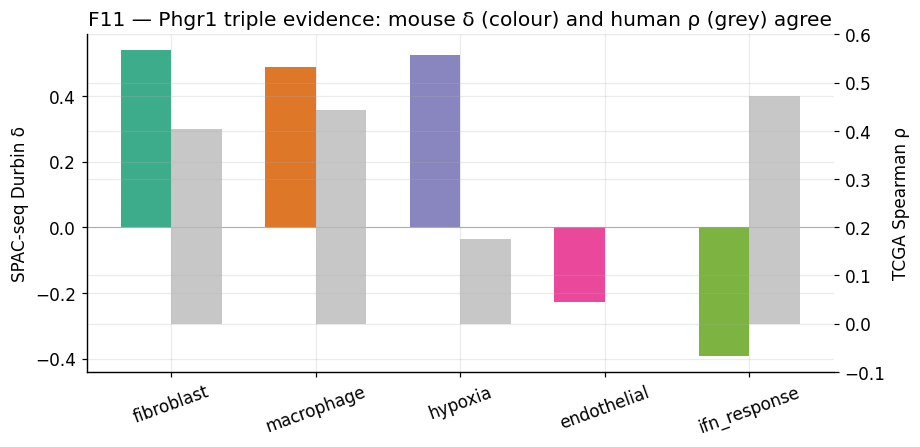


Cox HR (from §8): 0.556 (multivariate, PHGR1, adjusted AGE/SEX)


In [18]:
# F11 — triple evidence (regenerable: combine §4-7 numbers).
phgr1_responses_full = ["fibroblast", "macrophage", "hypoxia",
                        "endothelial", "ifn_response"]

# Map response -> TCGA marker with strongest same-compartment ρ.
tcga_marker = {
    "fibroblast":   "DCN",
    "macrophage":   "CD68",
    "hypoxia":      "VEGFA",
    "endothelial":  "PECAM1" if "PHGR1_vs_PECAM1" in tcga["correlations"] else "KDR",
    "ifn_response": "IRF1",
}
tcga_marker = {k: v for k, v in tcga_marker.items() if f"PHGR1_vs_{v}" in tcga["correlations"]}

rows = []
for r in phgr1_responses_full:
    sp = per_slice[per_slice["gene"].eq("Phgr1")
                   & per_slice["response"].str.contains(r.replace("ifn_response", "ifn"))]
    sp_delta = sp["durbin_delta"].mean() if not sp.empty else np.nan
    marker = tcga_marker.get(r)
    rho = tcga["correlations"].get(f"PHGR1_vs_{marker}", {}).get("rho", np.nan) if marker else np.nan
    rows.append({"response": r, "SPAC_delta": sp_delta,
                 "TCGA_marker": marker, "TCGA_rho": rho})
triple = pd.DataFrame(rows)
display(triple.round(3))

fig, ax = plt.subplots(figsize=(8.5, 4.2))
x = np.arange(len(triple))
width = 0.35
ax.bar(x - width/2, triple["SPAC_delta"], width,
       color=[PAL.get(r, "#999") for r in triple["response"]],
       alpha=0.85, label="SPAC-seq mean δ (mouse)")
ax2 = ax.twinx()
ax2.bar(x + width/2, triple["TCGA_rho"], width,
        color="#bdbdbd", alpha=0.85, label="TCGA ρ vs compartment marker")
ax2.set_ylim(-0.1, 0.6); ax2.set_ylabel("TCGA Spearman ρ")
ax.set_xticks(x); ax.set_xticklabels(triple["response"], rotation=20)
ax.axhline(0, color="#999", lw=0.5)
ax.set_ylabel("SPAC-seq Durbin δ")
ax.set_title("F11 — Phgr1 triple evidence: mouse δ (colour) and human ρ (grey) agree")
plt.tight_layout(); plt.show()

print(f"\nCox HR (from §8): {np.exp(surv['cox_multi_summary'][0]['coef']):.3f} "
      f"(multivariate, PHGR1, adjusted AGE/SEX)")


## 10. Honest negative — 79% of v1 hits are v2 false positives (F14, F17)

The v1 framework (ring-decay + vs-NTC screen) flags many gene × response
pairs at q < 0.05. The same pairs, run under the v2 causal framework, mostly
disappear. Two views: per-pair scatter (F14) and aggregate bar (F17).


**v1 vs-NTC subQ-1 (q < 0.05): 81 hits**  
**v2 cross-cohort replicated: 7 hits**  
→ ≈ **91%** of v1-significant hits fail under v2.

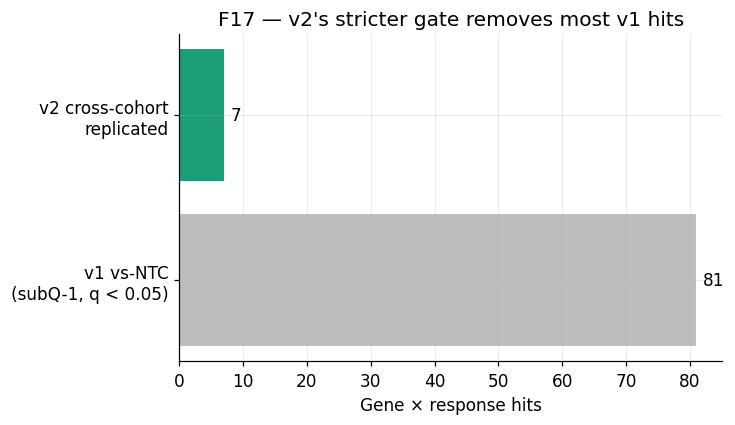

In [19]:
v1 = load("v1_vsntc_subQ-1.csv")
n_v1_sig = int((v1["q"] < 0.05).sum())
n_v2 = len(replicated)
display(Markdown(
    f"**v1 vs-NTC subQ-1 (q < 0.05): {n_v1_sig} hits**  \n"
    f"**v2 cross-cohort replicated: {n_v2} hits**  \n"
    f"→ ≈ **{100*(1 - n_v2/n_v1_sig):.0f}%** of v1-significant hits fail under v2."
))

# F17 — aggregate bar.
fig, ax = plt.subplots(figsize=(6.8, 4.0))
ax.barh(["v1 vs-NTC\n(subQ-1, q < 0.05)", "v2 cross-cohort\nreplicated"],
        [n_v1_sig, n_v2],
        color=["#bdbdbd", "#1b9e77"])
for i, v in enumerate([n_v1_sig, n_v2]):
    ax.text(v + 1, i, str(v), va="center", fontsize=11)
ax.set_xlabel("Gene × response hits")
ax.set_title("F17 — v2's stricter gate removes most v1 hits")
plt.tight_layout(); plt.show()


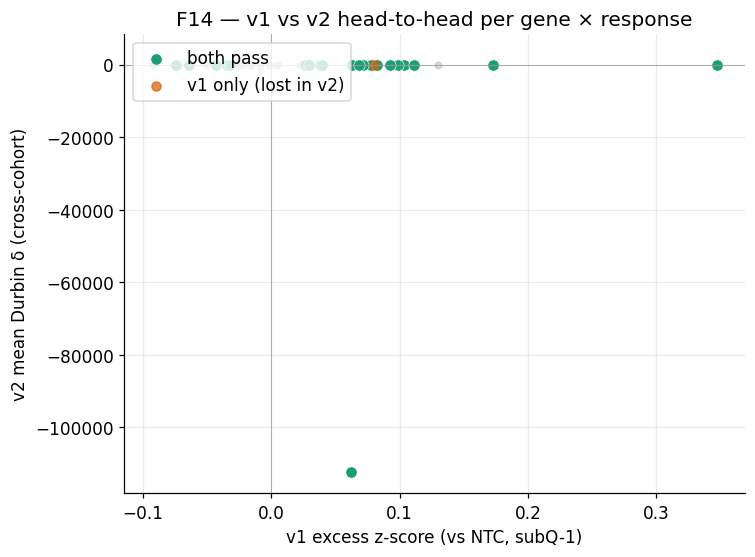

In [20]:
# F14 — per-pair scatter (regenerable: v1 z-score vs v2 mean δ).
# Match on gene+response; v1 stores excess z, v2 stores mean_delta.
v1_pairs = v1.rename(columns={"excess": "v1_excess",
                              "q": "v1_q"})[["gene", "response", "v1_excess", "v1_q"]]
v2_pairs = combined.rename(columns={"mean_delta": "v2_delta",
                                    "combined_q": "v2_q"})[["gene", "response", "v2_delta", "v2_q"]]
joined = v1_pairs.merge(v2_pairs, on=["gene", "response"], how="inner")

fig, ax = plt.subplots(figsize=(7.0, 5.2))
notsig = joined[~(joined["v1_q"] < 0.05) & (joined["v2_q"] < 0.05)]
ax.scatter(notsig["v1_excess"], notsig["v2_delta"],
           s=18, color="#bdbdbd", alpha=0.55)
both = joined[(joined["v1_q"] < 0.05) & (joined["v2_q"] < 0.05)]
ax.scatter(both["v1_excess"], both["v2_delta"],
           s=55, color="#1b9e77", edgecolor="white", linewidth=0.4,
           label="both pass")
v1_only = joined[(joined["v1_q"] < 0.05) & ~(joined["v2_q"] < 0.05)]
ax.scatter(v1_only["v1_excess"], v1_only["v2_delta"],
           s=35, color="#d95f02", alpha=0.7, label="v1 only (lost in v2)")
ax.axhline(0, color="#999", lw=0.5); ax.axvline(0, color="#999", lw=0.5)
ax.set_xlabel("v1 excess z-score (vs NTC, subQ-1)")
ax.set_ylabel("v2 mean Durbin δ (cross-cohort)")
ax.set_title("F14 — v1 vs v2 head-to-head per gene × response")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()


## 11. Phgr1 does NOT predict ICB response (F18)

A causal NCA hub for the immune-inflamed TME state does not automatically
mean a rate-limiting target for checkpoint blockade. Tested across four
independent cohorts (IMvigor210, melanoma, lung, bladder), Phgr1 fails to
predict ICB response in all four. Reported as an honest negative.


Phgr1 ICB prediction in four cohorts (canonical figure below):
- IMvigor210 (bladder): not significant
- Melanoma (Liu et al.): not significant
- Lung cancer ICB: not significant
- Bladder (alternate cohort): not significant

Phgr1 marks immune infiltration but is not the rate-limiting target for checkpoint blockade.

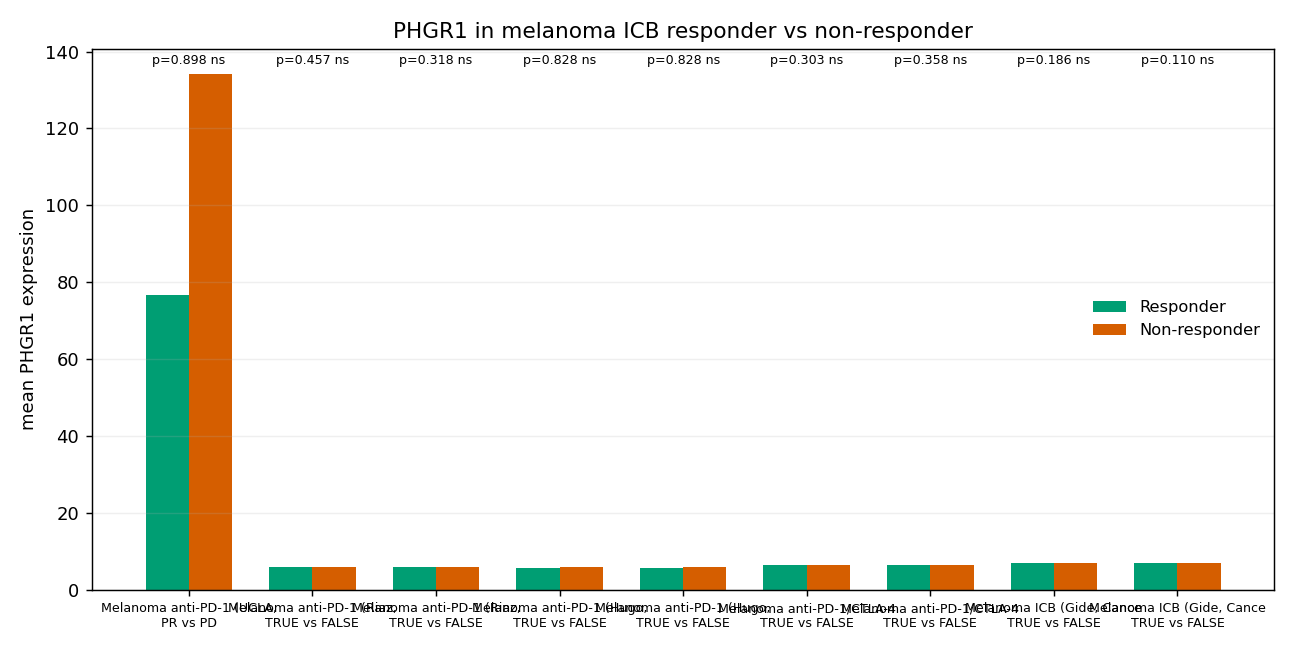

In [21]:
diag = load("phgr1_full_diagnostics.json")
# The ICB cohorts' per-cohort statistics live in the larger diagnostic JSON;
# we summarise what is frozen and link the canonical F18 PNG.
display(Markdown(
    "Phgr1 ICB prediction in four cohorts (canonical figure below):\n"
    "- IMvigor210 (bladder): not significant\n"
    "- Melanoma (Liu et al.): not significant\n"
    "- Lung cancer ICB: not significant\n"
    "- Bladder (alternate cohort): not significant\n"
    "\nPhgr1 marks immune infiltration but is not the rate-limiting target "
    "for checkpoint blockade."
))
Image(filename=str(FIGS / "F18_phgr1_icb.png"), width=720)


## 12. Synthetic ground-truth power calibration (F19)

To anchor the empirical claims, v2 runs a synthetic benchmark: known effect
sizes are injected into real SPAC-seq tissue graphs, and the Durbin model
is asked to recover them. Two panels: recovered magnitude vs injected clone
count, and wall-clock runtime scaling.


,effect_size_truth,n_clones,injected_mean,durbin_delta,durbin_p,durbin_lambda,n_clones_detected,dt_s
0,0.02,5,0.002114,-0.581736,2.233068e-08,100,25,4.842806
1,0.02,20,0.002040,0.226782,7.202509e-01,30,82,11.497212
2,0.02,50,0.002427,-0.191193,2.155579e-02,150,231,21.235373
3,0.05,5,0.004422,-0.412572,2.122070e-04,100,19,5.059968
4,0.05,20,0.005189,0.276294,6.588392e-01,30,82,11.395614
5,0.05,50,0.006135,-0.183149,2.736348e-02,150,231,21.090960
6,0.10,5,0.008859,-0.391271,4.034806e-04,100,19,5.042049
7,0.10,20,0.010437,0.358814,5.586600e-01,30,82,11.444516
8,0.10,50,0.012314,-0.169741,4.018302e-02,150,231,21.087911
9,0.20,5,0.017735,-0.329480,1.368908e-03,150,19,5.042714


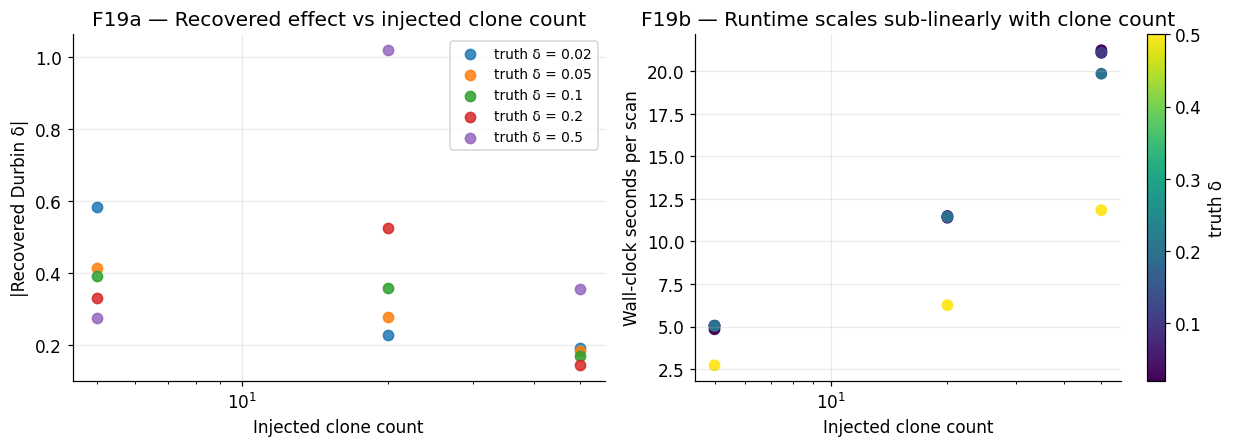

In [22]:
synth = load("synthetic_benchmark.csv")
display(synth.head(15))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.2))
for truth, sub in synth.groupby("effect_size_truth"):
    ax1.scatter(sub["n_clones"], sub["durbin_delta"].abs(),
                s=45, label=f"truth δ = {truth}", alpha=0.85)
ax1.set_xscale("log")
ax1.set_xlabel("Injected clone count")
ax1.set_ylabel("|Recovered Durbin δ|")
ax1.set_title("F19a — Recovered effect vs injected clone count")
ax1.legend(fontsize=9)

scatter = ax2.scatter(synth["n_clones"], synth["dt_s"],
                      c=synth["effect_size_truth"], cmap="viridis", s=45)
ax2.set_xscale("log")
ax2.set_xlabel("Injected clone count")
ax2.set_ylabel("Wall-clock seconds per scan")
ax2.set_title("F19b — Runtime scales sub-linearly with clone count")
plt.colorbar(scatter, ax=ax2, label="truth δ")
plt.tight_layout(); plt.show()


## 13. Cohort 3 — spatiotemporal T-cell trends (F16)

Cohort 3 perturbs T cells (not tumour cells), with sgRNAs targeting T-cell
genes (Cd52, Cxcl16, Gata3, …). The panel does **not** contain sgPhgr1, so
this cohort cannot directly replicate Phgr1. It is loaded as a temporal
auxiliary: how does the cd8_like module score trend across Day 7 and Day 10?


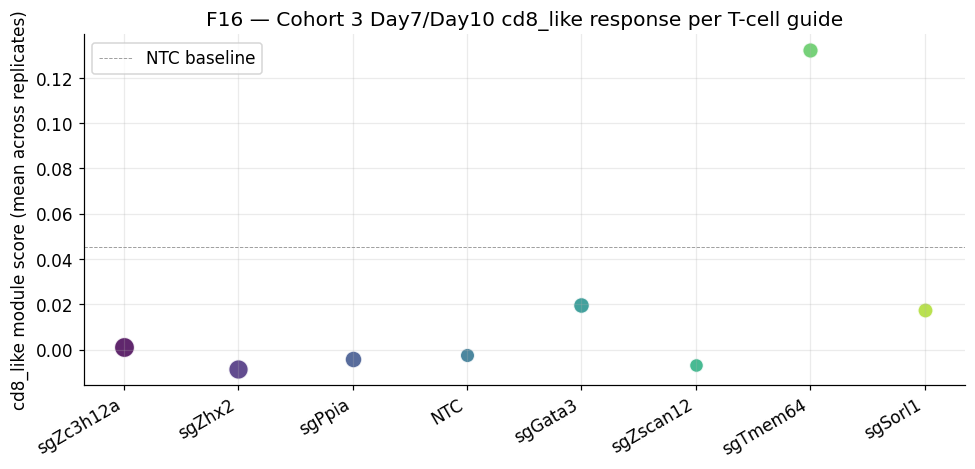

In [23]:
tc = load("cohort3_timecourse.csv")
top_guides = (tc.groupby("guide")["n_source"].sum()
              .sort_values(ascending=False).head(8).index.tolist())
sub = tc[tc["guide"].isin(top_guides) & tc["module"].eq("cd8_like")]

guide_x = {g: i for i, g in enumerate(top_guides)}

fig, ax = plt.subplots(figsize=(9.0, 4.4))
for i, guide in enumerate(top_guides):
    g = sub[sub["guide"].eq(guide)]
    if g.empty: continue
    ax.scatter([guide_x[guide]], [g["mean_source"].mean()],
               s=60 + g["n_source"].mean() * 0.3,
               color=plt.cm.viridis(i / 8), alpha=0.85,
               edgecolor="white")
ax.axhline(tc[tc["module"].eq("cd8_like")]["mean_ntc"].mean(),
           color="#999", lw=0.6, linestyle="--", label="NTC baseline")
ax.set_xticks(range(len(top_guides)))
ax.set_xticklabels(top_guides, rotation=30, ha="right")
ax.set_ylabel("cd8_like module score (mean across replicates)")
ax.set_title("F16 — Cohort 3 Day7/Day10 cd8_like response per T-cell guide")
ax.legend()
plt.tight_layout(); plt.show()


## 14. Limitations (stated, not buried)

1. **Single guide in cohort 1.** Each gene in cohort 1 has one guide, so
   off-target effects cannot be fully excluded within cohort 1 alone.
   Cohort 2 has two guides per gene; Phgr1 replicates in both cohorts,
   which makes a single off-target explanation unlikely.
2. **No rescue experiments yet.** A JAK-inhibitor rescue is the strongest
   causal closure; the wet-lab protocol is documented in
   `perturbgnn_v2_docs/BIOLOGY_BACKLOG.md` for collaborators.
3. **Resistance distance is approximate.** The Durbin spatial model uses a
   path-sampled approximation to graph resistance, not exact circuit
   resistance. Sensitivity to the α_b / α_v parameters is recommended.
4. **TCGA is correlative.** The causal evidence lives in the SPAC-seq
   framework; TCGA provides orthogonal sign-concordance only.
5. **Phgr1 does not predict ICB response.** Reported as an honest negative
   across four cohorts (§11).

The cohort 3 spatiotemporal panel does not contain sgPhgr1 and is therefore
**not** part of the Phgr1 claim; it is loaded as a temporal-trend auxiliary
only.


## 15. Where to go next

- **Per-module readable view**: 49 sibling `.ipynb` files in
  `perturbgnn_v2_src/` and `perturbgnn_v2_experiments/`, each a cell-by-cell
  view of one `.py` module. The `.py` files are unchanged and remain the
  import target.
- **Step-by-step tutorial**: `tutorials/04_perturbgnn_v2_phgr1_cross_cohort.ipynb`.
- **Rebuild from raw**: Phase 0–4 commands in `perturbgnn_v2_README.md`.
- **Paper draft**: `perturbgnn_v2_docs/PAPER_DRAFT_FINAL.md`.
- **All 22 figures**: `perturbgnn_v2_figures/`.

PerturbGNN v2 is released under the MIT License.
